In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
import matplotlib.pyplot as plt

from Demos.win32cred_demo import target
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure

root = tk.Tk()
root.withdraw()           # ছোট উইন্ডো লুকিয়ে রাখে

file_path = filedialog.askopenfilename(
    title="heart.csv ফাইল সিলেক্ট করুন",
    filetypes=[("CSV files", "*.csv")]
)

if file_path:
    df = pd.read_csv(file_path)
    display(df.head(10))     # Jupyter-এ সুন্দর করে দেখাবে
else:
    print("কোনো ফাইল বেছে নেওয়া হয়নি")

{'Flags': 4, 'Type': 2, 'TargetName': 'ebooctory@outlook.com', 'Comment': 'Created by win32cred_demo.py', 'LastWritten': pywintypes.datetime(2026, 1, 31, 0, 45, 31, 185000, tzinfo=TimeZoneInfo('GMT Standard Time', True)), 'CredentialBlob': b'', 'Persist': 3, 'Attributes': ({'Keyword': 'attr1', 'Flags': 0, 'Value': b'u\x00n\x00i\x00c\x00o\x00d\x00e\x00 \x00d\x00a\x00t\x00a\x00'}, {'Keyword': 'attr2', 'Flags': 0, 'Value': b'character data'}), 'TargetAlias': None, 'UserName': 'ebooctory@outlook.com'}
Failed to login for some reason (1326, 'LogonUser', 'The user name or password is incorrect.')


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


1
সারাংশ (সবচেয়ে গুরুত্বপূর্ণ পয়েন্ট)

একটা নিউমেরিক্যাল ফিচারের ডিস্ট্রিবিউশন শেপ (skewed right/left, normal, multimodal, outliers ইত্যাদি) বোঝার জন্য সবচেয়ে উপযুক্ত এবং স্ট্যান্ডার্ড প্লট হলো Histogram।

সুতরাং সঠিক উত্তর: Histogram
উদাহরণ কোড (seaborn/matplotlib):



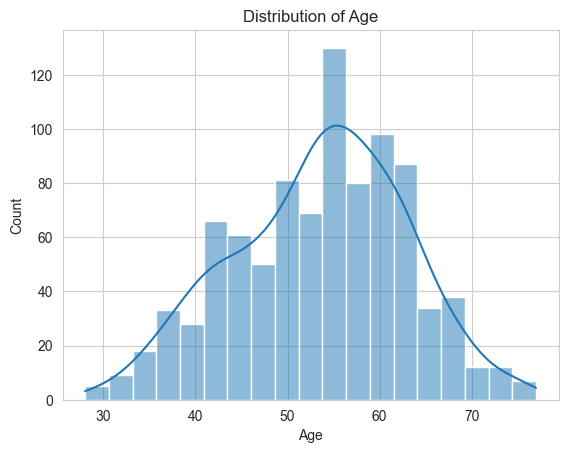

In [12]:


import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='Age', kde=True)   # kde=True দিলে smooth curve দেখা যায়
plt.title("Distribution of Age")
plt.show()




Boxplot কীভাবে কাজ করে (সহজ ব্যাখ্যা)

বক্সের মাঝখানে লাইন → মিডিয়ান
বক্সের নিচের/উপরের লাইন → Q1 (25%) এবং Q3 (75%)
বক্সের দৈর্ঘ্য → IQR (Interquartile Range = Q3 - Q1) → ডেটার মাঝামাঝি ৫০% এর স্প্রেড দেখায়
বক্সের বাইরে লাইন → whiskers (সাধারণত 1.5 × IQR পর্যন্ত)
বক্সের বাইরে ডট/পয়েন্ট → আউটলায়ার (অস্বাভাবিক মান)

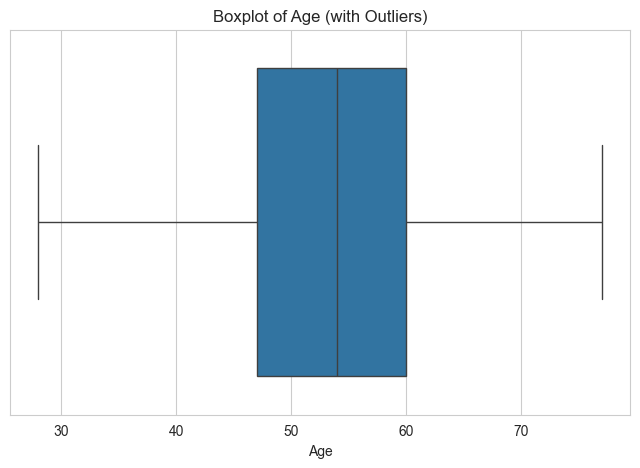

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Age'])   # অথবা y='Age', hue='HeartDisease' দিয়ে গ্রুপ করে দেখা যায়
plt.title("Boxplot of Age (with Outliers)")
plt.show()

Scatter plot কীভাবে লিনিয়ার রিলেশনশিপ দেখায়?

যদি পয়েন্টগুলো উপরের দিকে ঢালু হয় → positive linear relationship (যেমন: Age বাড়লে Blood Pressure বাড়ে)
যদি নিচের দিকে ঢালু হয় → negative linear relationship
যদি ছড়িয়ে-ছিটিয়ে থাকে → no linear relationship
যদি কার্ভড প্যাটার্ন হয় → non-linear

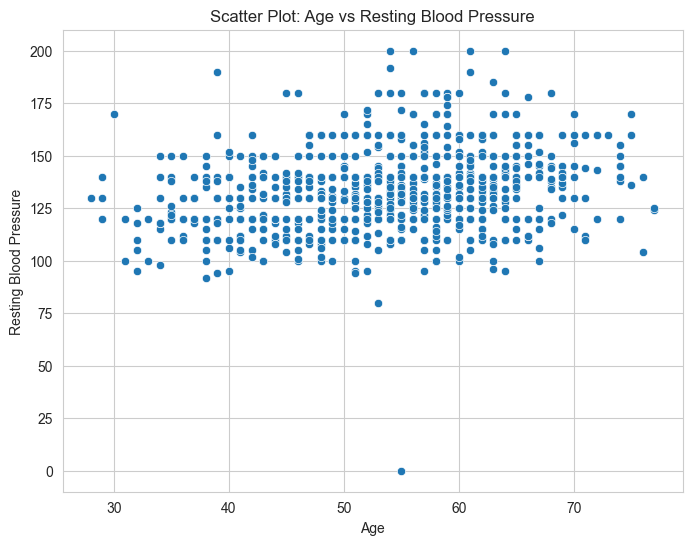

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Age', y='RestingBP')   # দুটি নিউমেরিক্যাল কলাম
plt.title("Scatter Plot: Age vs Resting Blood Pressure")
plt.xlabel("Age")
plt.ylabel("Resting Blood Pressure")
plt.show()

অতিরিক্ত টিপ: লিনিয়ারিটি আরও নিশ্চিত করতে Pearson correlation coefficient দেখতে পারেন:

In [15]:
print(df['Age'].corr(df['RestingBP']))   # -1 থেকে +1 এর মধ্যে মান

0.2543993561515447


Correlation Heatmap কীভাবে কাজ করে? (সহজ ব্যাখ্যা)

প্রতিটি সেলে একটা সংখ্যা থাকে: -1 থেকে +1 (Pearson correlation)
+1 → পুরোপুরি positive linear relationship (একটা বাড়লে অন্যটা ঠিক ততটাই বাড়ে)
-1 → পুরোপুরি negative linear relationship
0 → কোনো লিনিয়ার সম্পর্ক নেই

রঙ দিয়ে দেখানো হয়:
লাল/গোলাপি → positive strong correlation
নীল → negative strong correlation
সাদা/হালকা → weak বা no correlation

সারাংশ:
Correlation Heatmap-এর প্রাইমারি উদ্দেশ্য হলো একাধিক নিউমেরিক্যাল ফিচারের মধ্যে লিনিয়ার সম্পর্কের শক্তি (strength) এবং দিক (positive/negative) দ্রুত এবং স্পষ্টভাবে বিশ্লেষণ করা।
সুতরাং সঠিক উত্তর: Strength of linear relationships between numerical features

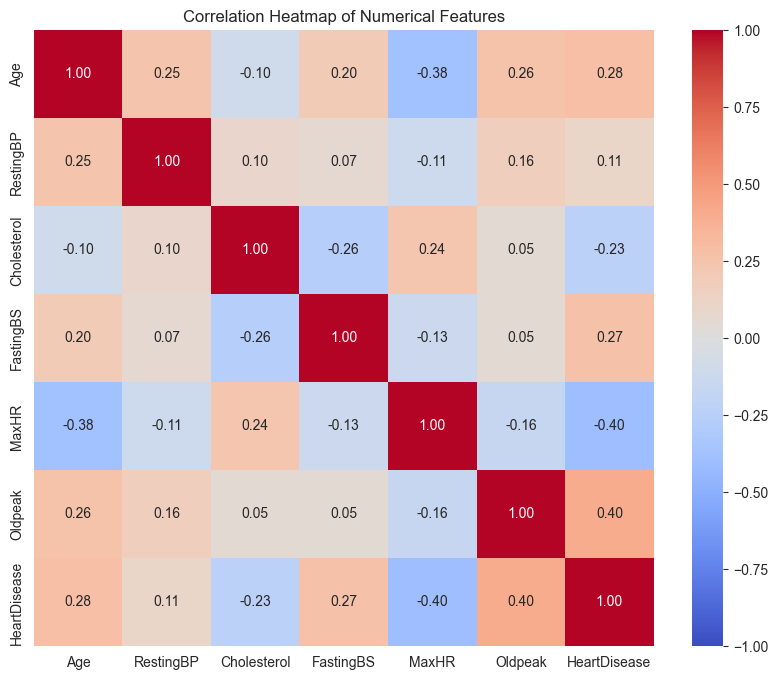

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# শুধু নিউমেরিক্যাল কলাম নিয়ে কোরিলেশন ম্যাট্রিক্স
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

সঠিক উত্তর: Need for resampling or class weighting
কেন এটাই সঠিক?
যখন একটা টার্গেট ভ্যারিয়েবল (target variable) খুবই ইমব্যালেন্সড হয় (যেমন: 95% ক্লাস 0 এবং মাত্র 5% ক্লাস 1), তাহলে এর অর্থ হলো:

মডেলটা মেজরিটি ক্লাস (যেটা বেশি আছে) শিখতে সহজেই ভালো অ্যাকুরেসি পেয়ে যায়, কিন্তু মাইনরিটি ক্লাস (যেটা কম আছে) ভালোভাবে শিখতে পারে না।
ফলে মডেল overfitting করে না বরং bias হয়ে যায় মেজরিটি ক্লাসের দিকে।
প্রেডিকশন মাইনরিটি ক্লাসের ক্ষেত্রে খুব খারাপ হয় (যেমন: হার্ট ডিজিজ প্রেডিকশনে মাত্র 5% পজিটিভ কেস থাকলে মডেল সবাইকে "No Disease" বলে দিতে পারে এবং 95% অ্যাকুরেসি পেয়ে যায় — কিন্তু আসল কাজে ব্যর্থ)।

এই সমস্যা সমাধানের জন্য প্রধানত যা করা হয়:

Resampling:
Oversampling (SMOTE, RandomOverSampler) — মাইনরিটি ক্লাসের ডেটা বাড়ানো
Undersampling — মেজরিটি ক্লাসের ডেটা কমানো

Class weighting:
মডেলের loss function-এ মাইনরিটি ক্লাসকে বেশি ওজন দেওয়া (যেমন: class_weight='balanced' in scikit-learn)

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
# অথবা ম্যানুয়ালি: class_weight={0:1, 1:10}  # minority ক্লাসকে বেশি ওজন
print(model)

RandomForestClassifier(class_weight='balanced', random_state=42)


সঠিক উত্তর: describe() and info()
কেন describe() এবং info() সবচেয়ে উপযুক্ত?
এই দুটি পদ্ধতি EDA-র প্রথম এবং সবচেয়ে গুরুত্বপূর্ণ স্টেপগুলোর মধ্যে একটা — যেটা ডেটা টাইপ, রেঞ্জ, মিসিং ভ্যালু, বেসিক স্ট্যাটিসটিক্স চেক করতে সাহায্য করে।


describe() এবং info() কীভাবে রিজনেবল ডেটা টাইপ ও রেঞ্জ চেক করে?

df.info() দেখায়:
প্রতিটি কলামের ডেটা টাইপ (int64, float64, object ইত্যাদি)
কতগুলো নন-নাল ভ্যালু আছে (মিসিং ভ্যালু চেক)
যদি Age-এর টাইপ object হয় → ভুল (এটা int/float হওয়া উচিত)

df.describe() দেখায় (নিউমেরিক্যাল কলামের জন্য):
count, mean, std, min, 25%, 50%, 75%, max
উদাহরণ: যদি Cholesterol-এর min = -10 বা max = 10000 হয় → অযৌক্তিক (রেঞ্জ চেক)
Age-এর max = 150 হলে → সম্ভবত ডেটা এন্ট্রি ভুল

In [19]:
# প্রথম স্টেপে সবসময় করা উচিত
print(df.info())          # ডেটা টাইপ + মিসিং ভ্যালু
print("\nSummary Statistics:")
print(df.describe())      # রেঞ্জ, mean, min/max চেক

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Summary Statistics:
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.

সঠিক উত্তর: Boxplot grouped by target
কেন Boxplot grouped by target সবচেয়ে উপযুক্ত?
এই প্রশ্নের মূল উদ্দেশ্য: একটা নিউমেরিক্যাল ফিচারের ডিস্ট্রিবিউশন (বিতরণ) কীভাবে টার্গেট ক্লাস (0 এবং 1) এর মধ্যে আলাদা হয় তা তুলনা করা।

Boxplot grouped by target কেন সেরা?

দুটি বক্স সাইড-বাই-সাইড দেখায় → HeartDisease=0 এবং =1 এর জন্য আলাদা আলাদা বক্স
এক নজরে বোঝা যায়:
মিডিয়ান কোন গ্রুপে বেশি?
ডেটার স্প্রেড (IQR) কোন গ্রুপে বড়?
আউটলায়ার কোন গ্রুপে বেশি?
দুটি গ্রুপের ডিস্ট্রিবিউশন কতটা আলাদা?

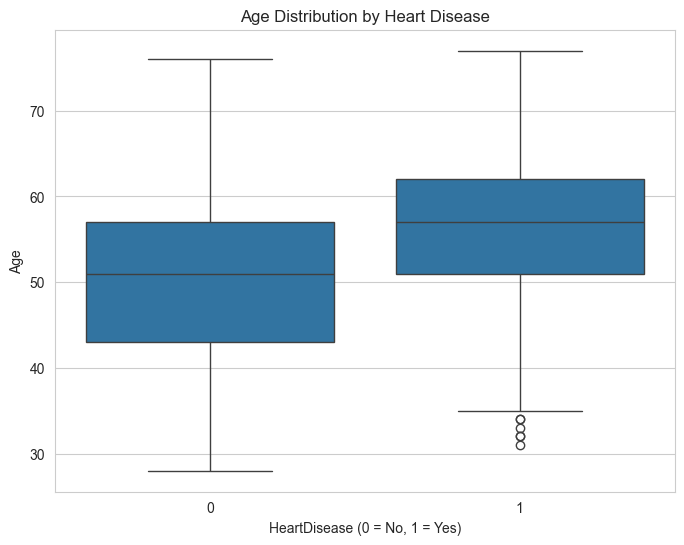

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='HeartDisease', y='Age')   # HeartDisease (0/1) অনুসারে Age-এর বক্সপ্লট
plt.title("Age Distribution by Heart Disease")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

সঠিক উত্তর: Exploring pairwise relationships among multiple numerical variables
কেন Pairplot এই কাজের জন্য সবচেয়ে উপযোগী?
Pairplot হলো seaborn-এর একটা খুব শক্তিশালী এবং জনপ্রিয় টুল, যেটা একাধিক নিউমেরিক্যাল ফিচারের মধ্যে pairwise সম্পর্ক (pairwise relationships) দ্রুত এবং সুন্দরভাবে দেখাতে ব্যবহার করা হয়।


Pairplot কীভাবে কাজ করে? (সহজ ব্যাখ্যা)

ডায়াগোনাল (diagonal): প্রতিটি ফিচারের নিজের ডিস্ট্রিবিউশন (histogram বা KDE plot)
অফ-ডায়াগোনাল: দুটি ফিচারের মধ্যে scatter plot (যেখানে সম্পর্ক, ক্লাস্টার, আউটলায়ার দেখা যায়)
hue= দিয়ে টার্গেট ক্লাস দিলে: প্রতিটি পয়েন্ট রঙিন হয়ে ক্লাস অনুসারে আলাদা দেখায় (যেমন HeartDisease 0 vs 1)

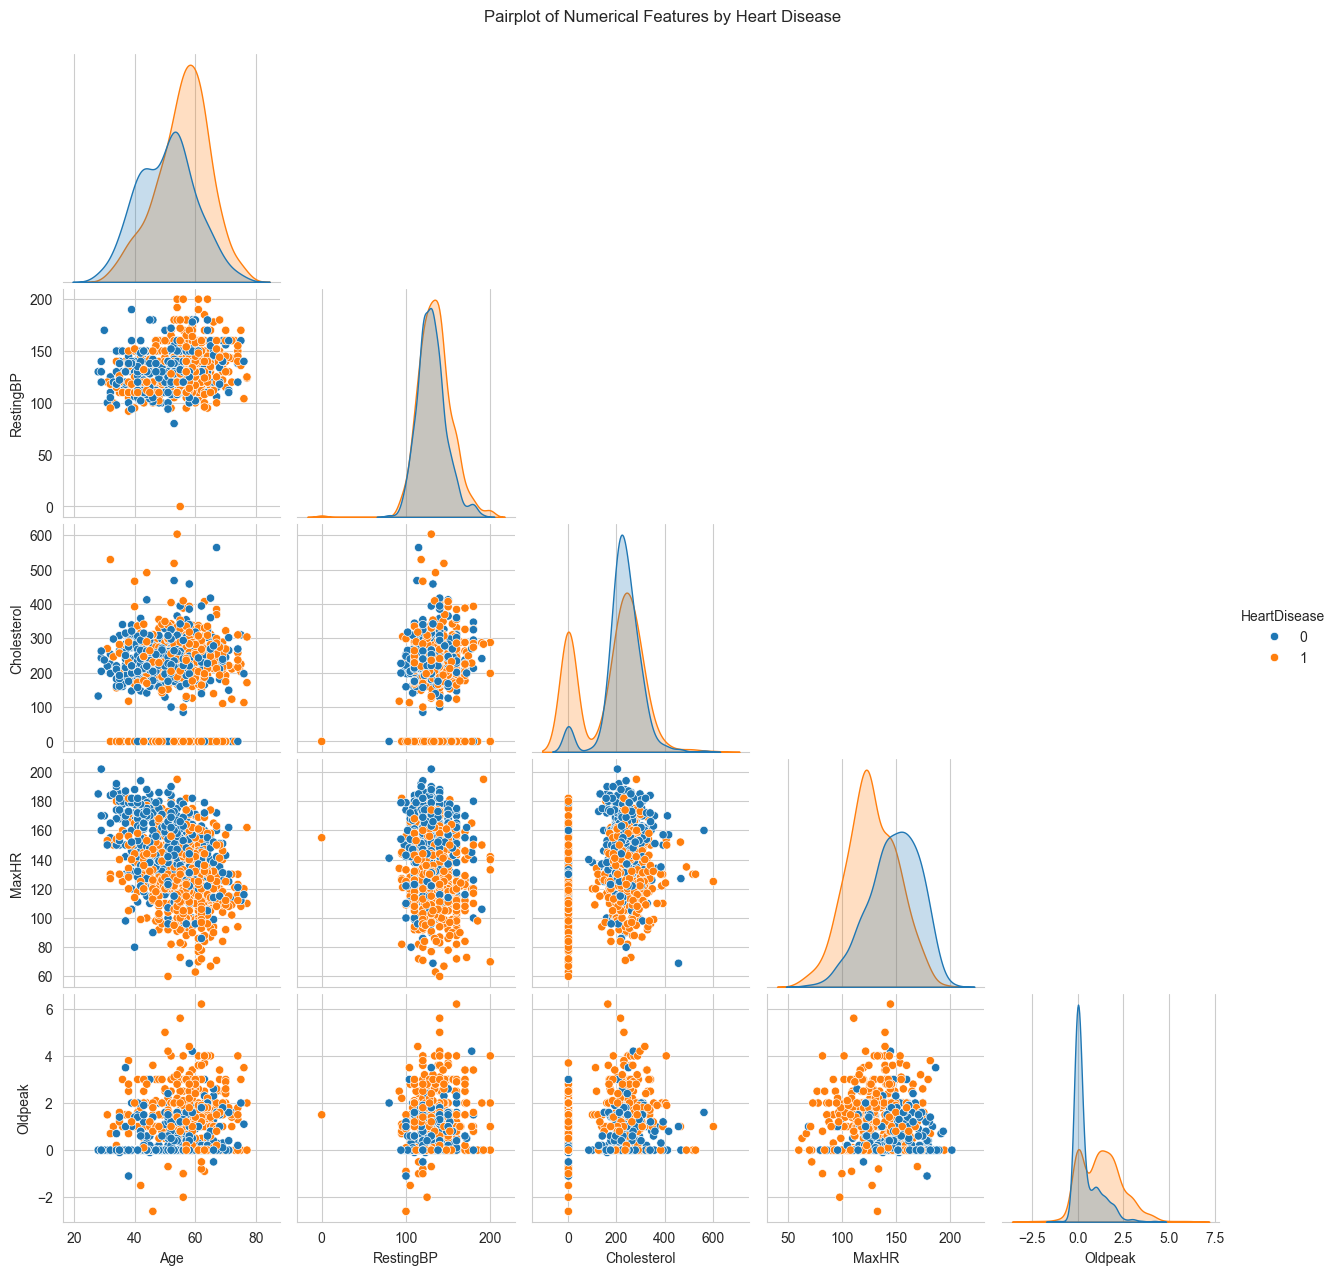

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# শুধু নিউমেরিক্যাল কলাম নিয়ে
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Pairplot
sns.pairplot(data=df[numeric_cols + ['HeartDisease']],
             hue='HeartDisease',      # টার্গেট দিয়ে রঙ করা
             diag_kind='kde',         # ডায়াগোনালে smooth curve
             corner=True)             # নিচের ট্রায়াঙ্গল অংশ বাদ দিয়ে শুধু উপরের অংশ দেখানো

plt.suptitle("Pairplot of Numerical Features by Heart Disease", y=1.02)
plt.show()

সঠিক উত্তর: Inspect shape, data types, and missing values
কেন এটাই সবচেয়ে ভালো প্রথম স্টেপ?
যেকোনো ডেটা অ্যানালাইসিস বা EDA (Exploratory Data Analysis) শুরু করার সবচেয়ে গুরুত্বপূর্ণ এবং প্রথম ধাপ হলো ডেটাসেটকে ভালোভাবে বোঝা। এর আগে কোনো ভিজুয়ালাইজেশন, মডেল বিল্ডিং বা ট্রান্সফরমেশন করা ঝুঁকিপূর্ণ কারণ আপনি জানেন না ডেটায় কী আছে।

প্রথম স্টেপে কী কী চেক করতে হয়? (স্ট্যান্ডার্ড প্র্যাকটিস)

Shape → কতগুলো রো এবং কলাম আছে

In [25]:
print(df.shape)          # উদাহরণ: (918, 12)

(918, 12)


Data types → প্রতিটি কলামের টাইপ ঠিক আছে কিনা (Age int হওয়া উচিত, object না)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Missing values → কোন কলামে কত মিসিং আছে

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


<Axes: >

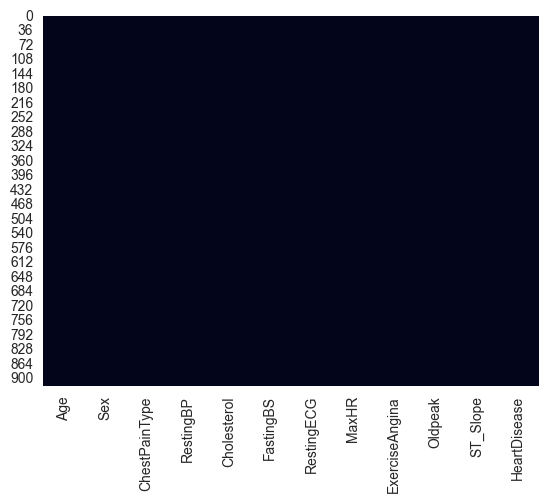

In [23]:
print(df.isnull().sum())
# অথবা
sns.heatmap(df.isnull(), cbar=False)  # মিসিং ভ্যালুর প্যাটার্ন দেখা

Basic overview (অতিরিক্ত ভালো প্র্যাকটিস)

In [22]:
df.describe()           # নিউমেরিক্যাল কলামের min/max/mean
df.head()               # প্রথম কয়েকটা রো দেখা
df.columns              # সব কলামের নাম

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

10
সারাংশ (কেন এটাই BEST first step?)

ভিজুয়ালাইজেশন শুরু করার আগে আপনাকে জানতে হবে:
ডেটা কত বড়?
কোন কলাম নিউমেরিক্যাল/ক্যাটাগরিক্যাল?
মিসিং ভ্যালু আছে কিনা?
রেঞ্জ/ভ্যালু অস্বাভাবিক কিনা?


এগুলো না জেনে প্লট করলে ভুল বোঝাবুঝি হবে (যেমন: মিসিং ভ্যালু থাকলে প্লটে NaN দেখাবে, টাইপ ভুল থাকলে এরর হবে)।
তাই সবচেয়ে ভালো প্রথম স্টেপ হলো:
Inspect shape, data types, and missing values
সুতরাং সঠিক উত্তর: Inspect shape, data types, and missing values

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

Percentage:
ChestPainType
ASY    54.030501
NAP    22.113290
ATA    18.845316
TA      5.010893
Name: proportion, dtype: float64


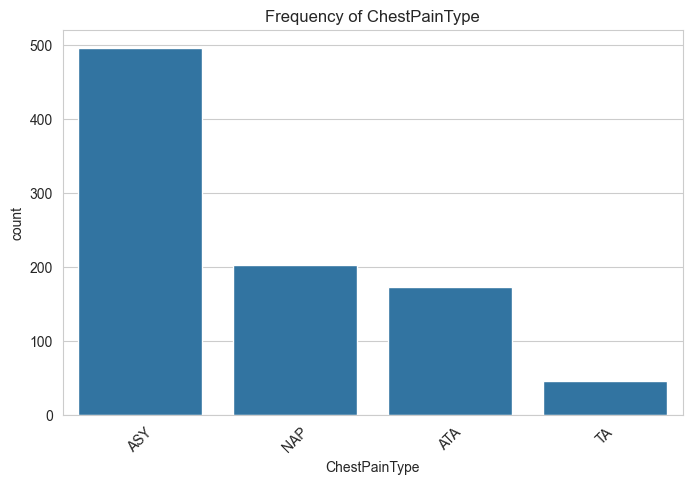

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# একটা ক্যাটাগরিক্যাল কলামের ফ্রিকোয়েন্সি
cat_col = 'ChestPainType'

print(df[cat_col].value_counts())
print("\nPercentage:")
print(df[cat_col].value_counts(normalize=True) * 100)

# ভিজুয়ালাইজেশন
plt.figure(figsize=(8,5))
sns.countplot(data=df, x=cat_col, order=df[cat_col].value_counts().index)
plt.title(f"Frequency of {cat_col}")
plt.xticks(rotation=45)
plt.show()

যদি কোনো ক্যাটাগরি ৫% এর কম হয় → সেটা rare বলে ধরা যায় এবং পরবর্তী স্টেপে হ্যান্ডেল করতে হবে।
সারাংশ:
ক্যাটাগরিক্যাল ফিচারের ফ্রিকোয়েন্সি এক্সপ্লোর করার মূল উদ্দেশ্য হলো দেখা যে কোনো ক্যাটাগরিতে খুব কম স্যাম্পল আছে কিনা (rare categories চিহ্নিত করা), যাতে মডেলিং-এ সমস্যা না হয়।
সুতরাং সঠিক উত্তর: To check if some categories have very few samples